<a href="https://colab.research.google.com/github/bhargavanarasimhaai24/Deep-Learning-Projects/blob/main/Perceptron%20%26%20Activation%20functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1

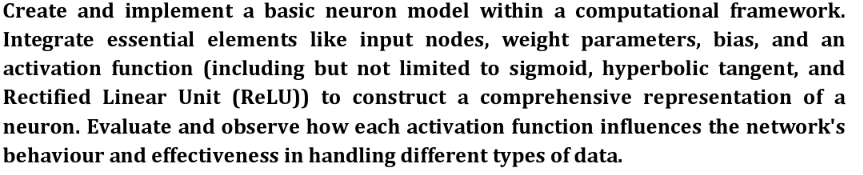

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
class Neuron:
  def __init__(self, input_size):
    self.weights = np.random.rand(input_size)
    self.bias = np.random.rand()

  def threshold_activation(self, x):
    return np.where(x < 0, 0, 1)

  def sigmoid(self, x):
    return 1/(1+np.exp(-x))

  def signum(self, x):
    return np.where(x < 0, -1, 1)

  def tanh(self, x):
    return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

  def ReLU(self, x):
    return np.maximum(0, x)

  def linear(self, x):
    return x

  def forward(self, inputs, activation):
    v_k = np.dot(inputs, self.weights)+self.bias
    return activation(v_k)

##Activity 01: Pass the inputs to the neuron and get the o/p

In [ ]:
#Considering Single Sample
print("Single Sample:")
my_neuron_1 = Neuron(input_size= 5)
X = np.random.rand(5) # x1, x2,..., x5
print(f"X = {X}")
print(f"Weight Matrix = {my_neuron_1.weights}")
print("Bias(b) =", my_neuron_1.bias)
print("My Neuron Output: sigmoid(W1*x1 + W2*x2 + ... + W5*x5 + b) ->",my_neuron_1.forward(X, my_neuron_1.sigmoid))
print("======"*20, "\n")

#Considering 4 Samples
print("Multiple Samples:")
my_neuron_2 = Neuron(input_size= 5)
X = np.random.rand(4, 5) # [x1, x2,..., x5] * 4 (4 such samples)
print(f"X = {X}, Shape: {X.shape}")
print()
print(f"Weight Matrix = {my_neuron_2.weights}")
print("Bias(b) =", my_neuron_2.bias)
outputs = []
for sample in X:
  y = (my_neuron_2.forward(sample, my_neuron_2.sigmoid)).item()
  outputs.append(y)
  print(f"{sample} -> {y}")
print("\nTherefore, My Neuron Outputs for all samples: ",outputs)
print("\nAs we observe the outputs, we will see that for any sample the o/p is in the range of 0-1")

Single Sample:
X = [0.71188969 0.87958441 0.90091472 0.77981405 0.42771443]
Weight Matrix = [0.10210712 0.10622443 0.98888692 0.19095758 0.48310723]
Bias(b) = 0.9246611292275302
My Neuron Output: sigmoid(W1*x1 + W2*x2 + ... + W5*x5 + b) -> 0.9119138019419802

Multiple Samples:
X = [[0.55552283 0.66155733 0.82553721 0.83771951 0.40181553]
 [0.45644984 0.04429711 0.60202025 0.25314266 0.41862834]
 [0.74834455 0.18225102 0.83702843 0.927014   0.6405292 ]
 [0.29399212 0.10775105 0.31073138 0.41230588 0.06621604]], Shape: (4, 5)

Weight Matrix = [0.75138118 0.76481399 0.27237088 0.94391034 0.97412359]
Bias(b) = 0.9465078064823877
[0.55552283 0.66155733 0.82553721 0.83771951 0.40181553] -> 0.9636273629363794
[0.45644984 0.04429711 0.60202025 0.25314266 0.41862834] -> 0.8941705016973917
[0.74834455 0.18225102 0.83702843 0.927014   0.6405292 ] -> 0.9669185905933365
[0.29399212 0.10775105 0.31073138 0.41230588 0.06621604] -> 0.8566983512396845

Therefore, My Neuron Outputs for all samples:  [0.

##Activity 02: Visualise activation functions

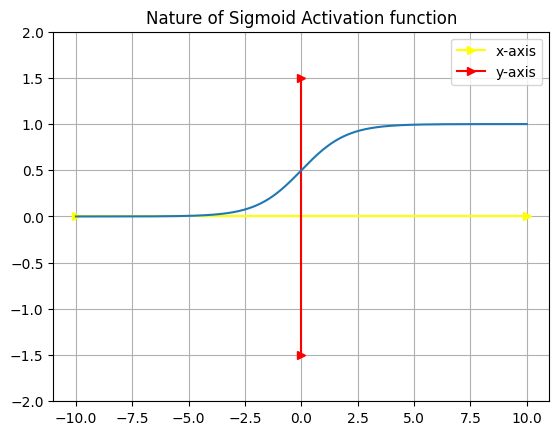

In [ ]:
from matplotlib.lines import lineStyles
def my_plot(X, y, name):

  #--------------------------(Optional, just to print X and Y axis)
  # For practice you can comment or delete these optional lines and click Run all
  x = np.linspace(-10, 10, 2)
  y1 = 0*x
  plt.plot(x, y1, c='yellow', label = 'x-axis', linestyle='-', marker='>')
  x = np.linspace(-1.5, 1.5, 2)
  y1 = 0*x
  plt.plot(y1, x, c='red', label = 'y-axis', linestyle='-', marker='>')
  plt.ylim(-2, 2)
  plt.legend()
  #--------------------------

  plt.plot(X, y)
  plt.title(f"Nature of {name} Activation function")
  plt.grid()
  plt.show()

X = np.linspace(-10, 10, 1000)
obj = Neuron(1)
y1 = obj.sigmoid(X)
my_plot(X, y1, "Sigmoid")

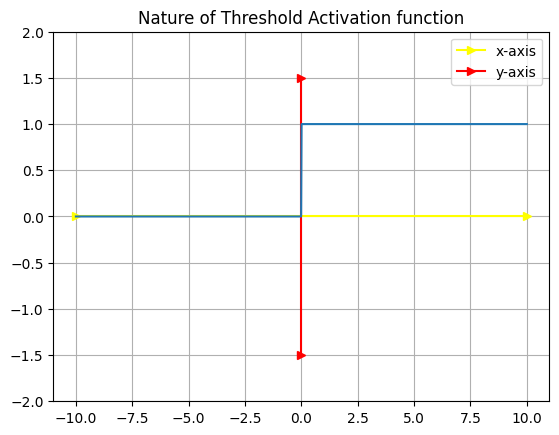

In [ ]:
y2 = obj.threshold_activation(X)
my_plot(X, y2, "Threshold")

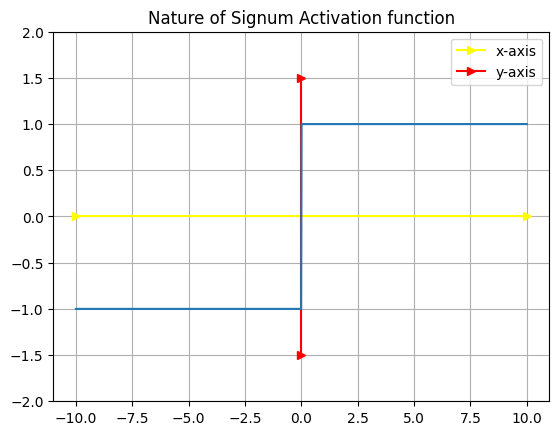

In [ ]:
y3 = obj.signum(X)
my_plot(X, y3, "Signum")

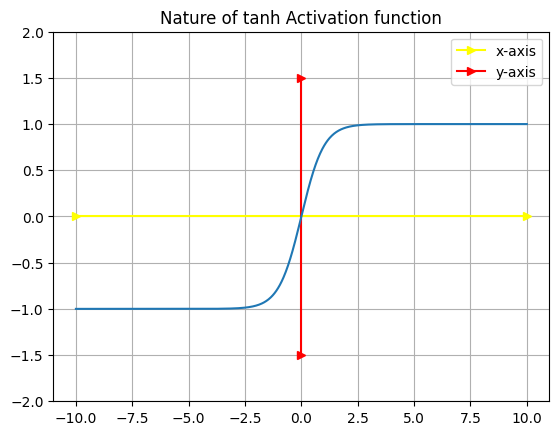

In [ ]:
y4 = obj.tanh(X)
my_plot(X, y4, "tanh")

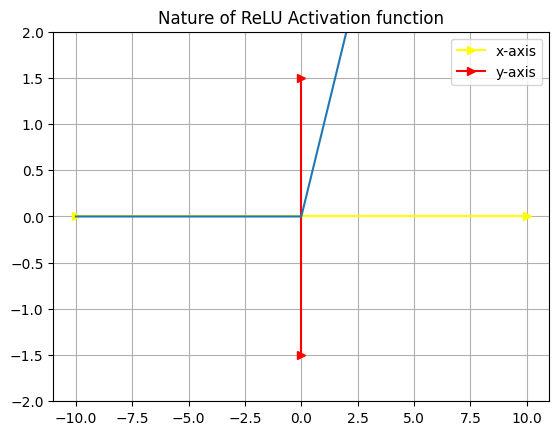

In [ ]:
y5 = obj.ReLU(X)
my_plot(X, y5, "ReLU")

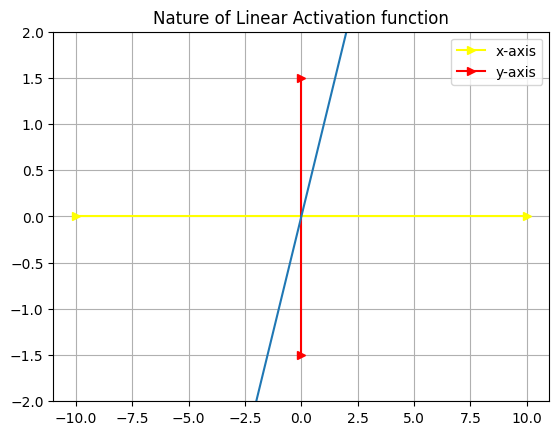

In [ ]:
y6 = obj.linear(X)
my_plot(X, y6, "Linear")

#2

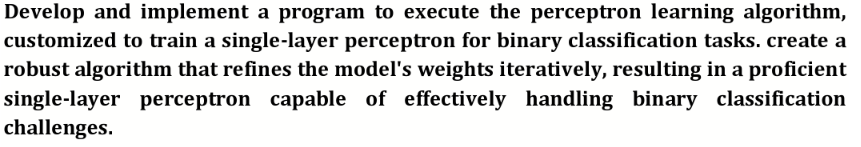

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

##AND

In [ ]:
class Perceptron:
  def __init__(self, epochs= 10, eta= 0.01):
    self.epochs = epochs
    self.eta = eta
    self.W = None
    self.b = None

  #Weights/ HyperParameters
  def initialise_weights(self, X):
    n_features = X.shape[0]
    np.random.seed(42)
    self.W = np.random.rand(n_features, 1)
    self.b = np.random.rand()

  def threshold_activation(self, x):
    return 0 if x<0 else 1

  #prediction
  def predict(self, X):
    v_k = (self.W.T @ X + self.b).item()
    y_hat = self.threshold_activation(v_k)
    return y_hat

  #Train(Tune our HyperParameters[W, b])
  def fit(self, X, y):
    self.initialise_weights(X)

    for epoch in range(self.epochs):

      for i in range(X.shape[1]):

        x_i = X[:, i:i+1]
        y_i = y[i]

        y_pred = self.predict(x_i)

        self.W = self.W + self.eta * (y_i - y_pred) * x_i
        self.b = self.b + self.eta * (y_i - y_pred)

  def plot(self, l, u, X, x_lims, y_lims):
    W_final, b_final = self.W, self.b
    x1 = np.linspace(l, u, 100)
    x2 = (- W_final[0]*x1 - b_final) / W_final[1]
    plt.scatter(X[0], X[1],c=y)
    plt.plot(x1, x2)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.xlim(x_lims[0], x_lims[1])
    plt.ylim(y_lims[0], y_lims[1])
    plt.grid()
    plt.title("Classifier Learned")
    plt.show()

Learned Parameters:
W:[[0.17454012]
 [0.35071431]]
b:-0.46800605818859486


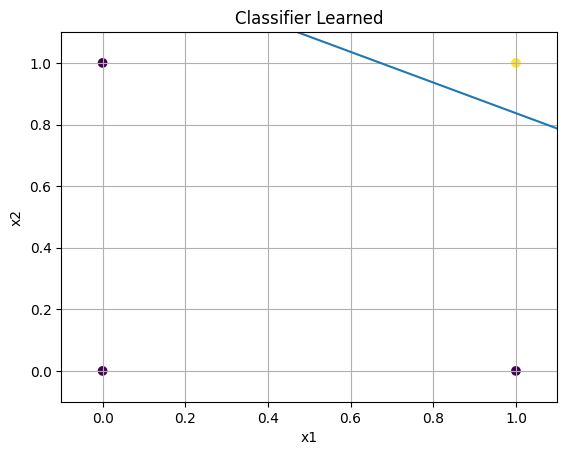

In [ ]:
X = np.array([[0, 0, 1, 1], [0, 1, 0, 1]])
y = np.array([0, 0, 0, 1])

obj = Perceptron(epochs=20, eta=0.1)
obj.fit(X, y)
W_final, b_final = obj.W, obj.b
print(f"Learned Parameters:\nW:{W_final}\nb:{b_final}")
obj.plot(0, 2, X, [-0.1, 1.1], [-0.1, 1.1])

##OR

Learned Parameters:
W:[[0.37454012]
 [0.95071431]]
b:-0.2680060581885949


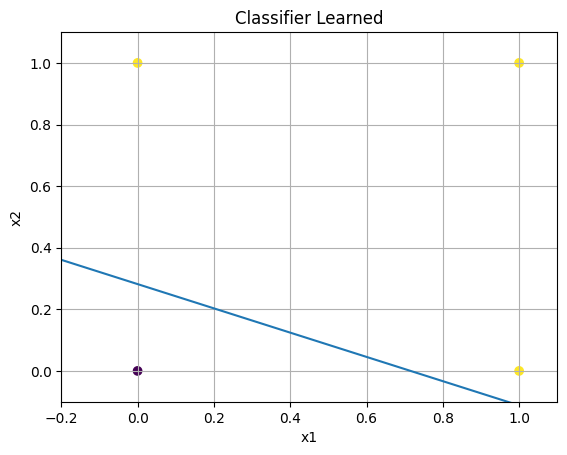

In [ ]:
X = np.array([[0, 0, 1, 1], [0, 1, 0, 1]])
y = np.array([0, 1, 1, 1])

obj = Perceptron(epochs=20, eta=1)
obj.fit(X, y)
W_final, b_final = obj.W, obj.b
print(f"Learned Parameters:\nW:{W_final}\nb:{b_final}")
obj.plot(-1, 2, X, [-0.2, 1.1], [-0.1, 1.1])

##Manual Example

Learned Parameters:
W:[[ 0.04454012]
 [-0.00928569]]
b:-0.07800605818859542


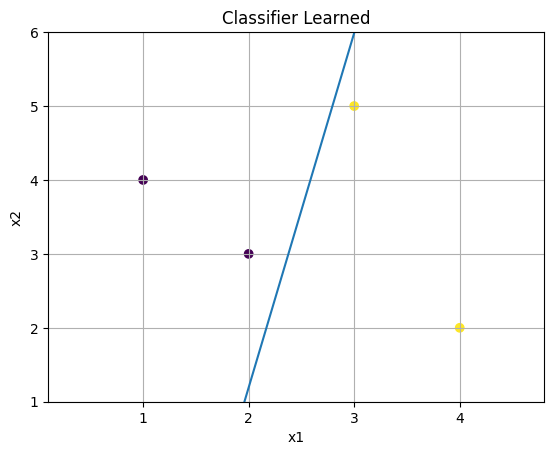

In [ ]:
X = np.array([[2, 1, 3, 4], [3, 4, 5, 2]])
y = np.array([0, 0, 1, 1])

obj = Perceptron(epochs=200, eta=0.01)
obj.fit(X, y)
W_final, b_final = obj.W, obj.b
print(f"Learned Parameters:\nW:{W_final}\nb:{b_final}")
obj.plot(0, 5, X, [0.1, 4.8], [1, 6])

In [ ]:
test_sample = np.array([2, 4])
pred = obj.predict(test_sample)
print("Prediction for [2, 4]:", pred)
print("The same can be inferred from Diagram")

Prediction for [2, 4]: 0
The same can be inferred from Diagram
